In [5]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path
sys.path.append('/root/capsule/code/beh_ephys_analysis')
from utils.ephys_functions import fitSpikeModelG
import platform
import os
from pathlib import Path
import shutil
from utils.beh_functions import session_dirs, get_session_tbl, makeSessionDF, parseSessionID
from utils.photometry_utils import get_FP_data
from matplotlib import pyplot as plt
from IPython.display import display
from scipy.signal import find_peaks
from harp.clock import align_timestamps_to_anchor_points
import numpy as np
from scipy.signal import butter, filtfilt, medfilt, sosfiltfilt
from scipy.optimize import curve_fit
import json
from sklearn.linear_model import LinearRegression
from matplotlib.gridspec import GridSpec
import pickle
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time

# %matplotlib widget
import re
import random
from matplotlib.gridspec import GridSpec
from utils.photometry_combine import population_GLM, plot_tuning_curve, plot_psth, population_GLM_ani
from contextlib import redirect_stdout
%matplotlib inline

In [6]:
session_csv = '/root/capsule/code/data_management/hopkins_FP_session_assets.csv'
session_tbl = pd.read_csv(session_csv)
session_list = session_tbl['session_id'].tolist()
target_folder = '/root/capsule/scratch/manuscript/F_photometry'

In [7]:
# session-wise GLM
region_curr = 'PL'
channel_curr = 'G_tri-exp_mc'
align_curr = 'choice_time'
window_size_curr = 2
thresh_curr = 0.5
formula = 'spikes ~ 1+outcome*ipsi+Qchosen+iso'
post = 3
pre = 2

params_dict_reward = {
    'region': region_curr,
    'channel': channel_curr,
    'align': align_curr,
    'window_size': window_size_curr,
    'formula': formula,
    'pre_time': pre,
    'post_time': post,
    'thresh': thresh_curr,
    'step_size': 0.1,
    'polar_regressors': ['outcome', 'Qchosen']
}


Session-wise GLM with parameters: 
Processing region: PL, channel: G_tri-exp_mc, align: choice_time, window size: 2, threshold: 0.5, formula: spikes ~ 1+outcome*ipsi+Qchosen+iso
Parsing session_id: behavior_669489_2023-06-27_14-20-19, aniID: 669489
Parsing session_id: behavior_669489_2023-06-27_14-20-19, aniID: 669489
Parsing session_id: behavior_669489_2023-06-24_14-56-01, aniID: 669489
Parsing session_id: behavior_669489_2023-07-03_11-31-11, aniID: 669489
Parsing session_id: behavior_669489_2023-06-26_16-23-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-29_16-16-02, aniID: 669489
Parsing session_id: behavior_669489_2023-07-03_11-31-11, aniID: 669489
Parsing session_id: behavior_669489_2023-06-24_14-56-01, aniID: 669489
Parsing session_id: behavior_669489_2023-06-26_16-23-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-29_16-16-02, aniID: 669489
Parsing session_id: behavior_669489_2023-07-05_15-44-55, aniID: 669489
Parsing session_id: behavior_669489_2023-

/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:306: RuntimeWarning: Mean of empty slice
  aligned_matrix[i, j] = np.nanmean(aligned_signal[window_mask])


Parsing session_id: behavior_754898_2024-12-30_17-40-08, aniID: 754898
Parsing session_id: behavior_754898_2025-01-01_20-40-03, aniID: 754898
Parsing session_id: behavior_754898_2024-12-30_17-40-08, aniID: 754898


/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:321: RuntimeWarning: Mean of empty slice
  mean_psth = np.nanmean(aligned_matrix, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Parsing session_id: behavior_754898_2025-01-01_20-40-03, aniID: 754898
Parsing session_id: behavior_754896_2025-01-06_16-37-09, aniID: 754896
Parsing session_id: behavior_754896_2025-01-06_16-37-09, aniID: 754896
Parsing session_id: behavior_754896_2025-01-08_16-03-27, aniID: 754896
Parsing session_id: behavior_754896_2025-01-08_16-03-27, aniID: 754896
Parsing session_id: behavior_754898_2025-01-02_17-54-29, aniID: 754898
Parsing session_id: behavior_754898_2025-01-02_17-54-29, aniID: 754898
Parsing session_id: behavior_754896_2025-01-07_14-08-54, aniID: 754896
Parsing session_id: behavior_754896_2025-01-07_14-08-54, aniID: 754896
Parsing session_id: behavior_754898_2024-12-26_16-22-54, aniID: 754898
Parsing session_id: behavior_754898_2024-12-26_16-22-54, aniID: 754898
Parsing session_id: behavior_754896_2025-01-09_16-22-47, aniID: 754896
Parsing session_id: behavior_754896_2025-01-09_16-22-47, aniID: 754896
Parsing session_id: behavior_754896_2025-01-03_17-20-19, aniID: 754896
Parsin

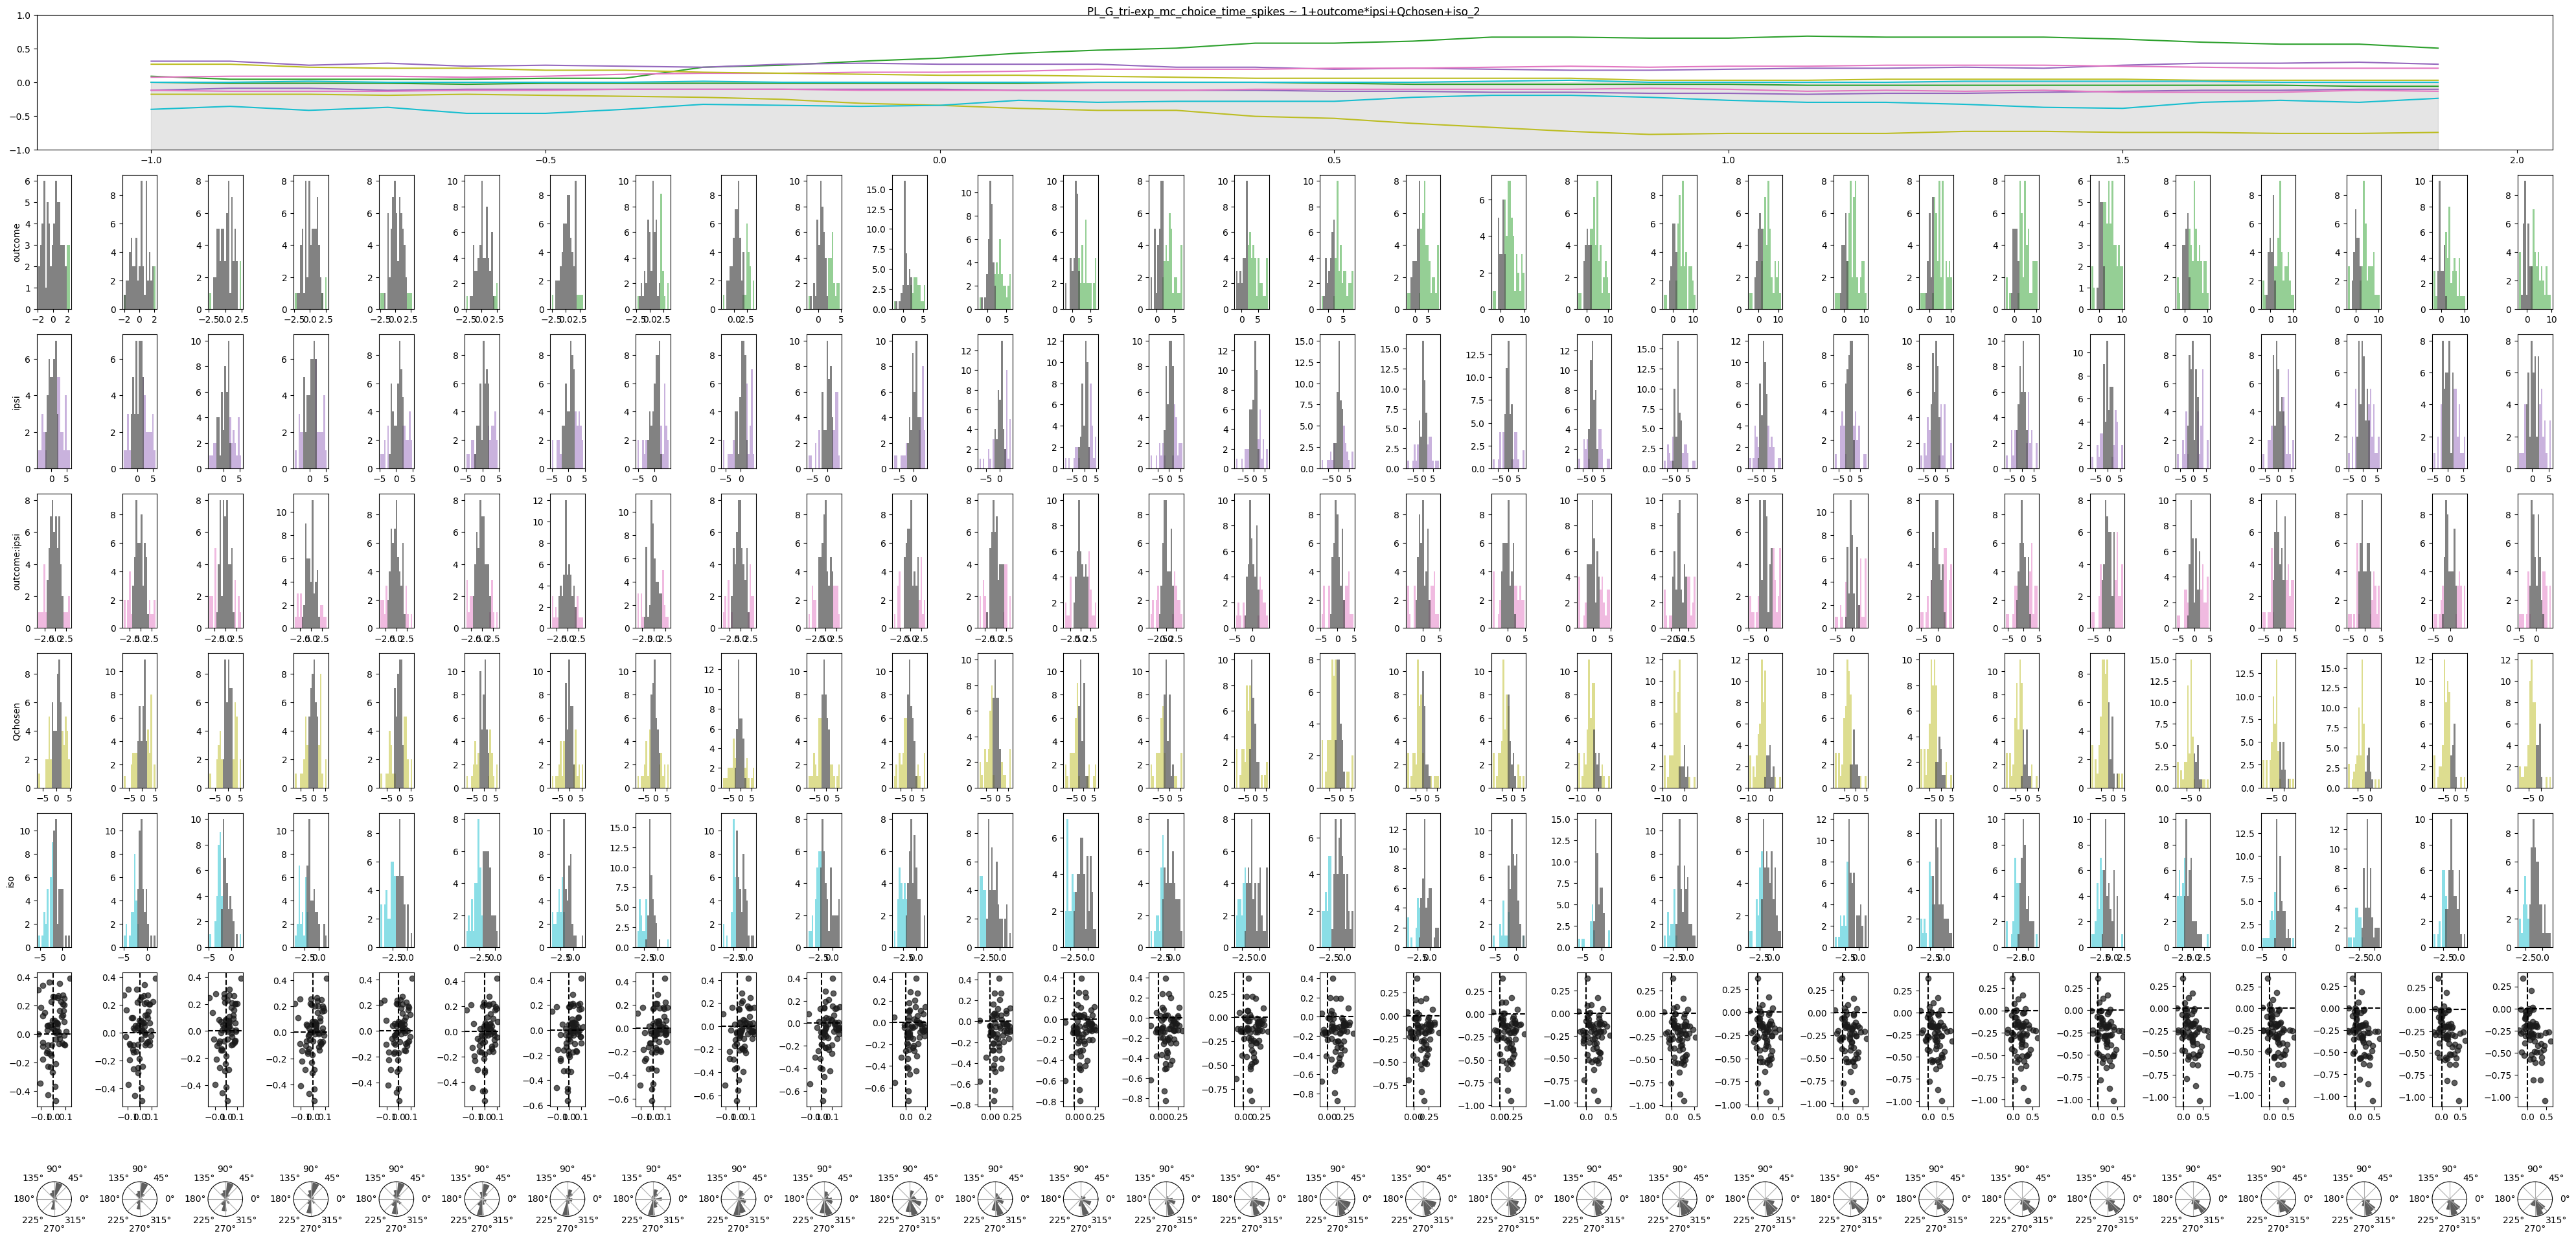

In [8]:

print(
    f"Session-wise GLM with parameters: \n"
    f"Processing region: {params_dict_reward['region']}, "
    f"channel: {params_dict_reward['channel']}, "
    f"align: {params_dict_reward['align']}, "
    f"window size: {params_dict_reward['window_size']}, "
    f"threshold: {params_dict_reward['thresh']}, "
    f"formula: {params_dict_reward['formula']}"
)

results = population_GLM(session_list, **params_dict_reward)

save_dir = os.path.join(target_folder, 'population_GLM_results')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
formula_clean = (
    params_dict_reward["formula"]
    .replace(" ", "")
    .replace("+", "_")
    .replace("*", "x")
    .split("~")[1]
)
file_name = (
    f"population_GLM_session-wise_{params_dict_reward['region']}_{params_dict_reward['channel']}_"
    f"{params_dict_reward['align']}_win{params_dict_reward['window_size']}_"
    f"thresh{params_dict_reward['thresh']}_formula_{formula_clean}.pkl"
)
with open(os.path.join(save_dir, file_name), 'wb') as f:
    pickle.dump(params_dict_reward, f)
    pickle.dump(results, f)
print(f'Saved results to {os.path.join(save_dir, file_name)}')
results['fig'].savefig(os.path.join(save_dir, file_name.replace('.pkl', '.pdf')), dpi=300)
results['fig'].show()

Animal-wise GLM with parameters: 
Processing region: PL, channel: G_tri-exp_mc, align: choice_time, window size: 2, threshold: 0.5, formula: spikes ~ 1+outcome*ipsi+Qchosen+iso
Parsing session_id: behavior_669489_2023-06-24_14-56-01, aniID: 669489
Parsing session_id: behavior_669489_2023-06-26_16-23-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-27_14-20-19, aniID: 669489
Parsing session_id: behavior_669489_2023-06-28_13-10-12, aniID: 669489
Parsing session_id: behavior_669489_2023-06-29_16-16-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-30_12-51-58, aniID: 669489
Parsing session_id: behavior_669489_2023-07-01_16-31-54, aniID: 669489
Parsing session_id: behavior_669489_2023-07-02_12-49-06, aniID: 669489
Parsing session_id: behavior_669489_2023-07-03_11-31-11, aniID: 669489
Parsing session_id: behavior_669489_2023-07-04_14-24-45, aniID: 669489
Parsing session_id: behavior_669489_2023-07-05_15-44-55, aniID: 669489
Parsing session_id: behavior_669489_2023-0

/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:306: RuntimeWarning: Mean of empty slice
  aligned_matrix[i, j] = np.nanmean(aligned_signal[window_mask])


Parsing session_id: behavior_701707_2024-01-13_18-07-21, aniID: 701707
Parsing session_id: behavior_701707_2024-01-13_18-07-21, aniID: 701707
Parsing session_id: behavior_701707_2024-01-13_18-07-21, aniID: 701707
Parsing session_id: behavior_669489_2023-07-03_11-31-11, aniID: 669489


/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:321: RuntimeWarning: Mean of empty slice
  mean_psth = np.nanmean(aligned_matrix, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Parsing session_id: behavior_699472_2024-01-06_14-52-56, aniID: 699472
Parsing session_id: behavior_699472_2024-01-06_14-52-56, aniID: 699472
Parsing session_id: behavior_699472_2024-01-06_14-52-56, aniID: 699472
Parsing session_id: behavior_669489_2023-07-03_11-31-11, aniID: 669489
Parsing session_id: behavior_754895_2025-01-09_15-08-04, aniID: 754895
Parsing session_id: behavior_754895_2025-01-09_15-08-04, aniID: 754895
Parsing session_id: behavior_669492_2023-07-04_17-17-58, aniID: 669492
Parsing session_id: behavior_669492_2023-07-04_17-17-58, aniID: 669492
Parsing session_id: behavior_669492_2023-07-04_17-17-58, aniID: 669492
Parsing session_id: behavior_672850_2023-07-03_17-29-31, aniID: 672850
Parsing session_id: behavior_672850_2023-07-03_17-29-31, aniID: 672850
Parsing session_id: behavior_672850_2023-07-03_17-29-31, aniID: 672850
Parsing session_id: behavior_699462_2024-01-11_10-59-40, aniID: 699462
Parsing session_id: behavior_699462_2024-01-11_10-59-40, aniID: 699462
Parsin

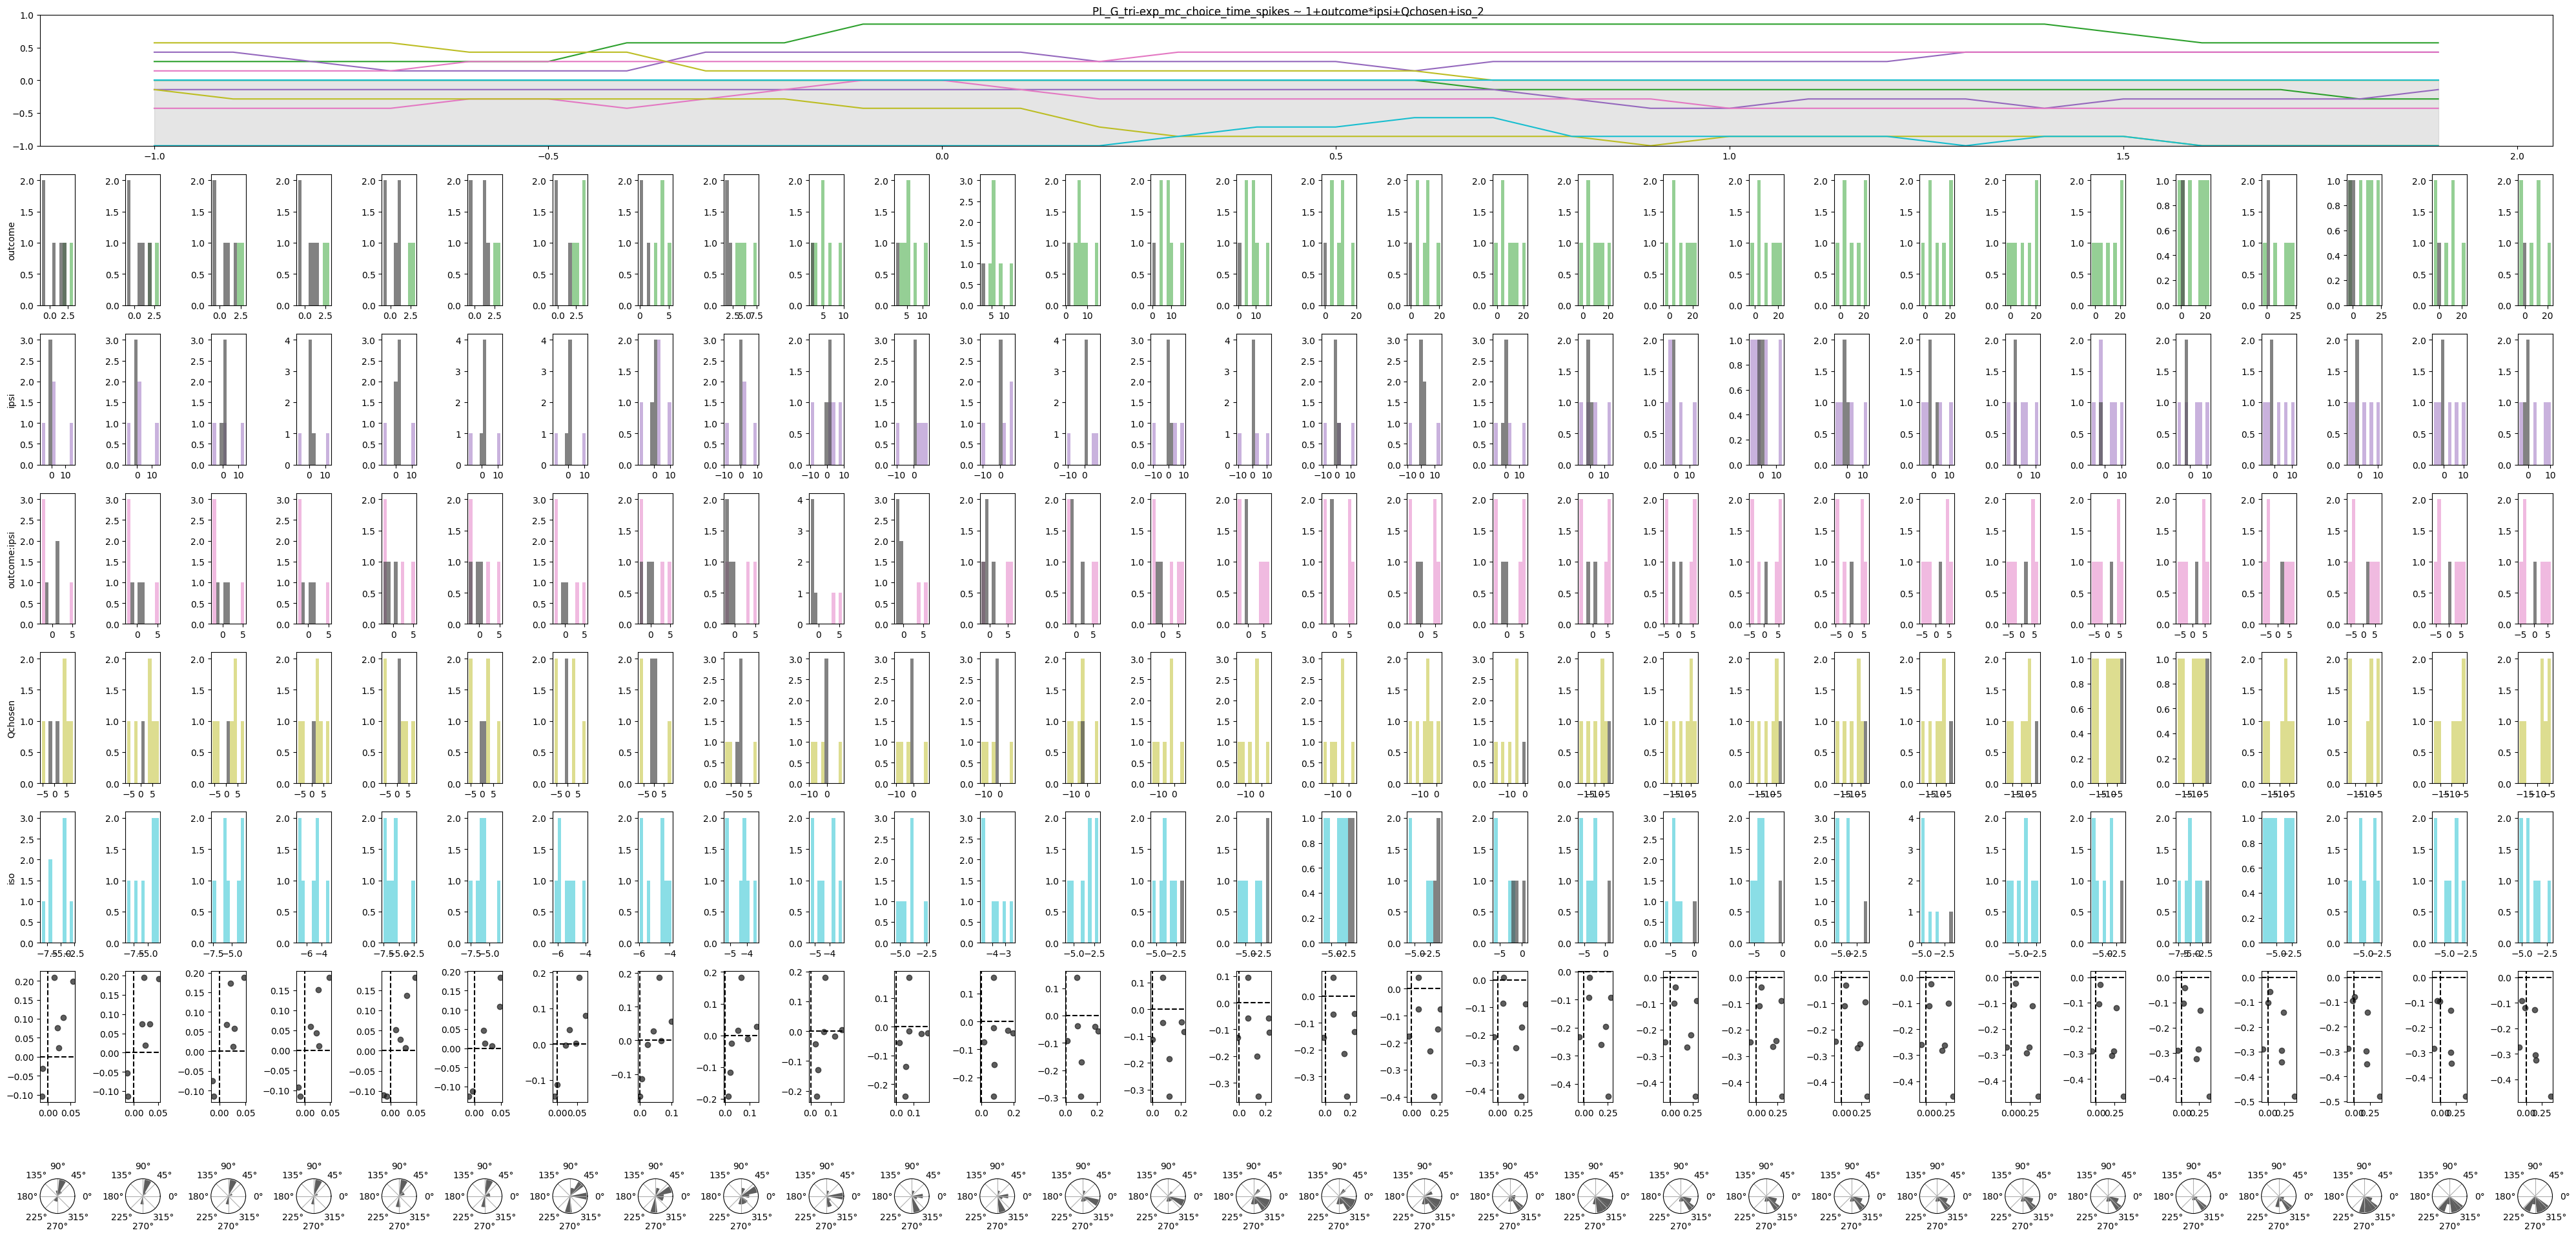

In [9]:
print(
    f"Animal-wise GLM with parameters: \n"
    f"Processing region: {params_dict_reward['region']}, "
    f"channel: {params_dict_reward['channel']}, "
    f"align: {params_dict_reward['align']}, "
    f"window size: {params_dict_reward['window_size']}, "
    f"threshold: {params_dict_reward['thresh']}, "
    f"formula: {params_dict_reward['formula']}"
)

results = population_GLM_ani(session_list, **params_dict_reward)

save_dir = os.path.join(target_folder, 'population_GLM_results')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
formula_clean = (
    params_dict_reward["formula"]
    .replace(" ", "")
    .replace("+", "_")
    .replace("*", "x")
    .split("~")[1]
)
file_name = (
    f"population_GLM_animal-wise_{params_dict_reward['region']}_{params_dict_reward['channel']}_"
    f"{params_dict_reward['align']}_win{params_dict_reward['window_size']}_"
    f"thresh{params_dict_reward['thresh']}_formula_{formula_clean}.pkl"
)
with open(os.path.join(save_dir, file_name), 'wb') as f:
    pickle.dump(params_dict_reward, f)
    pickle.dump(results, f)
print(f'Saved results to {os.path.join(save_dir, file_name)}')
results['fig'].savefig(os.path.join(save_dir, file_name.replace('.pkl', '.pdf')), dpi=300)
results['fig'].show()

Session-wise GLM with parameters: 
Processing region: PL, channel: G_tri-exp_mc, align: goCue_start_time, window size: 2, threshold: 0.5, formula: spikes ~ 1+hit+iso
Parsing session_id: behavior_669489_2023-06-24_14-56-01, aniID: 669489
Parsing session_id: behavior_669489_2023-06-26_16-23-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-27_14-20-19, aniID: 669489
Parsing session_id: behavior_669489_2023-06-28_13-10-12, aniID: 669489
Parsing session_id: behavior_669489_2023-06-29_16-16-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-30_12-51-58, aniID: 669489
Parsing session_id: behavior_669489_2023-07-01_16-31-54, aniID: 669489
Parsing session_id: behavior_669489_2023-07-02_12-49-06, aniID: 669489
Parsing session_id: behavior_669489_2023-07-03_11-31-11, aniID: 669489
Parsing session_id: behavior_669489_2023-07-04_14-24-45, aniID: 669489
Parsing session_id: behavior_669489_2023-07-05_15-44-55, aniID: 669489
Parsing session_id: behavior_669489_2023-07-06_13-50-

/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:306: RuntimeWarning: Mean of empty slice
  aligned_matrix[i, j] = np.nanmean(aligned_signal[window_mask])


Parsing session_id: behavior_754898_2025-01-01_20-40-03, aniID: 754898
Parsing session_id: behavior_754898_2025-01-01_20-40-03, aniID: 754898
Parsing session_id: behavior_754896_2025-01-08_16-03-27, aniID: 754896
Parsing session_id: behavior_754896_2025-01-08_16-03-27, aniID: 754896
Parsing session_id: behavior_754898_2024-12-28_19-23-45, aniID: 754898
Parsing session_id: behavior_754898_2024-12-28_19-23-45, aniID: 754898


/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:321: RuntimeWarning: Mean of empty slice
  mean_psth = np.nanmean(aligned_matrix, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Parsing session_id: behavior_754896_2025-01-07_14-08-54, aniID: 754896
Parsing session_id: behavior_754896_2025-01-07_14-08-54, aniID: 754896
Parsing session_id: behavior_754898_2025-01-02_17-54-29, aniID: 754898
Parsing session_id: behavior_754898_2024-12-30_17-40-08, aniID: 754898
Parsing session_id: behavior_754898_2024-12-30_17-40-08, aniID: 754898
Parsing session_id: behavior_754896_2025-01-04_17-25-58, aniID: 754896
Parsing session_id: behavior_754896_2025-01-04_17-25-58, aniID: 754896
Parsing session_id: behavior_754898_2025-01-02_17-54-29, aniID: 754898
Parsing session_id: behavior_754896_2025-01-09_16-22-47, aniID: 754896
Parsing session_id: behavior_754896_2025-01-09_16-22-47, aniID: 754896
Parsing session_id: behavior_754898_2024-12-26_16-22-54, aniID: 754898
Parsing session_id: behavior_754898_2025-01-04_18-49-39, aniID: 754898
Parsing session_id: behavior_754898_2024-12-26_16-22-54, aniID: 754898
Parsing session_id: behavior_754898_2025-01-01_20-40-03, aniID: 754898
Parsin

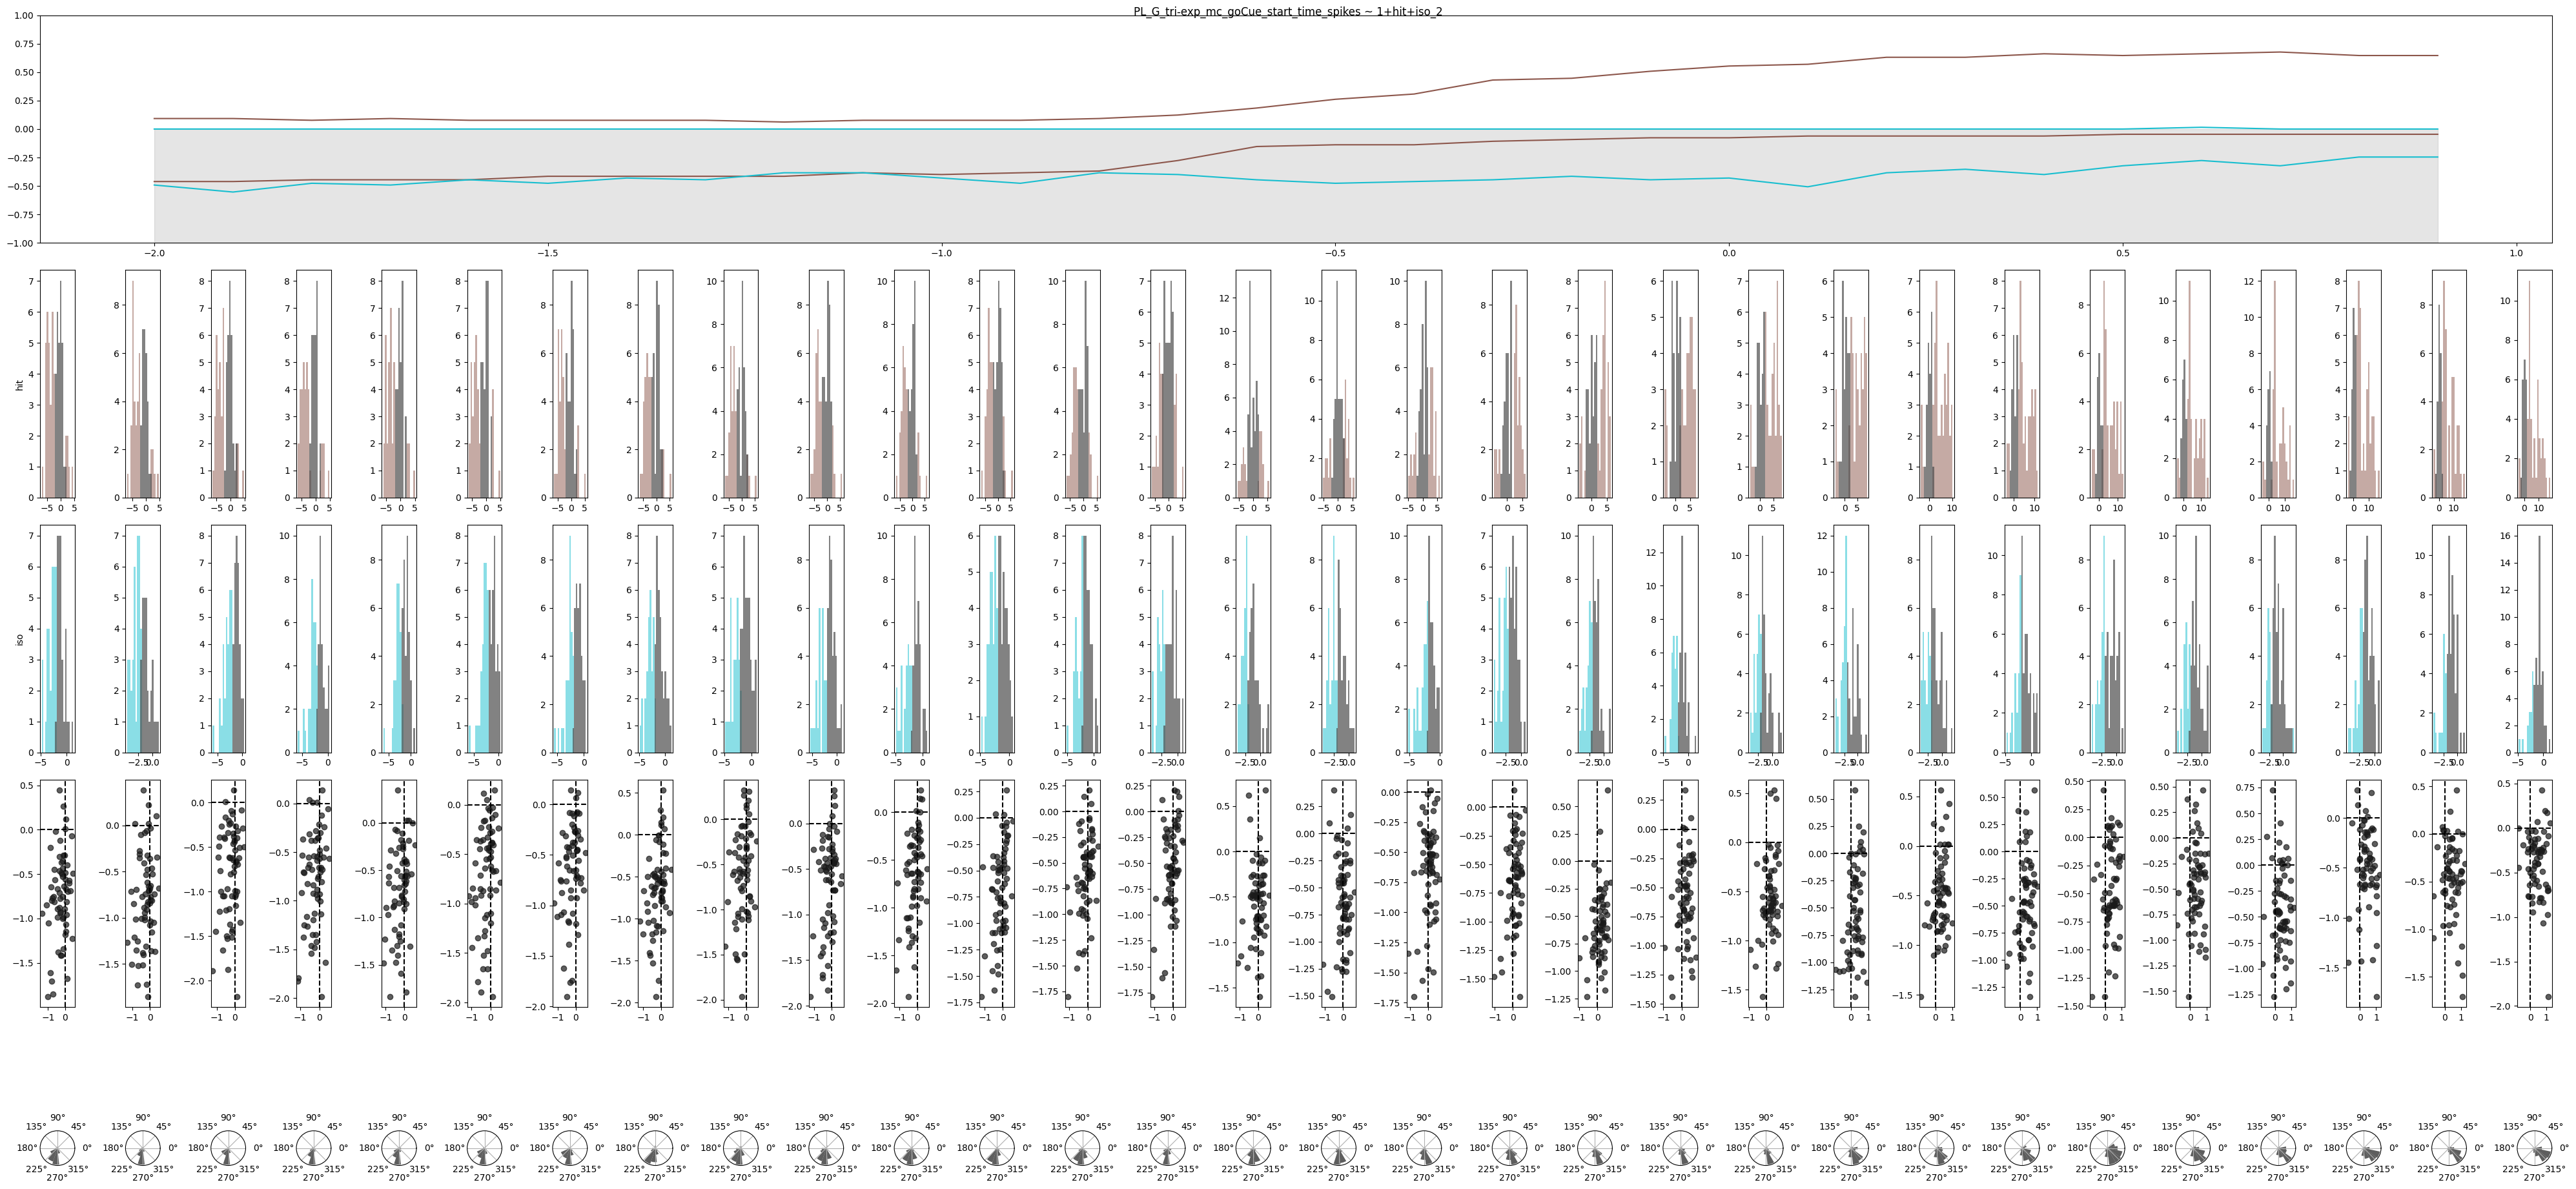

In [10]:
# session-wise GLM
region_curr = 'PL'
channel_curr = 'G_tri-exp_mc'
align_curr = 'goCue_start_time'
window_size_curr = 2
thresh_curr = 0.5
formula = 'spikes ~ 1+hit+iso'
post = 2
pre = 3

params_dict_hit = {
    'region': region_curr,
    'channel': channel_curr,
    'align': align_curr,
    'window_size': window_size_curr,
    'formula': formula,
    'pre_time': pre,
    'post_time': post,
    'thresh': thresh_curr,
    'step_size': 0.1,
    'polar_regressors': ['hit', 'iso']
}

print(
    f"Session-wise GLM with parameters: \n"
    f"Processing region: {params_dict_hit['region']}, "
    f"channel: {params_dict_hit['channel']}, "
    f"align: {params_dict_hit['align']}, "
    f"window size: {params_dict_hit['window_size']}, "
    f"threshold: {params_dict_hit['thresh']}, "
    f"formula: {params_dict_hit['formula']}"
)

results = population_GLM(session_list, **params_dict_hit)

save_dir = os.path.join(target_folder, 'population_GLM_results')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
formula_clean = (
    params_dict_hit["formula"]
    .replace(" ", "")
    .replace("+", "_")
    .replace("*", "x")
    .split("~")[1]
)
file_name = (
    f"population_GLM_session-wise_{params_dict_hit['region']}_{params_dict_hit['channel']}_"
    f"{params_dict_hit['align']}_win{params_dict_hit['window_size']}_"
    f"thresh{params_dict_hit['thresh']}_formula_{formula_clean}.pkl"
)
with open(os.path.join(save_dir, file_name), 'wb') as f:
    pickle.dump(params_dict_hit, f)
    pickle.dump(results, f)
print(f'Saved results to {os.path.join(save_dir, file_name)}')
results['fig'].savefig(os.path.join(save_dir, file_name.replace('.pkl', '.pdf')), dpi=300)
results['fig'].show()

Animal-wise GLM with parameters: 
Processing region: PL, channel: G_tri-exp_mc, align: goCue_start_time, window size: 2, threshold: 0.5, formula: spikes ~ 1+hit+iso
Parsing session_id: behavior_669489_2023-06-24_14-56-01, aniID: 669489
Parsing session_id: behavior_669489_2023-06-26_16-23-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-27_14-20-19, aniID: 669489
Parsing session_id: behavior_669489_2023-06-28_13-10-12, aniID: 669489
Parsing session_id: behavior_669489_2023-06-29_16-16-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-30_12-51-58, aniID: 669489
Parsing session_id: behavior_669489_2023-07-01_16-31-54, aniID: 669489
Parsing session_id: behavior_669489_2023-07-02_12-49-06, aniID: 669489
Parsing session_id: behavior_669489_2023-07-03_11-31-11, aniID: 669489
Parsing session_id: behavior_669489_2023-07-04_14-24-45, aniID: 669489
Parsing session_id: behavior_669489_2023-07-05_15-44-55, aniID: 669489
Parsing session_id: behavior_669489_2023-07-06_13-50-0

Parsing session_id: behavior_754895_2024-12-31_19-19-16, aniID: 754895
Parsing session_id: behavior_754895_2025-01-02_15-15-18, aniID: 754895
Parsing session_id: behavior_754895_2025-01-03_16-09-32, aniID: 754895
Parsing session_id: behavior_754895_2025-01-04_15-19-09, aniID: 754895
Parsing session_id: behavior_754895_2025-01-06_14-47-04, aniID: 754895
Parsing session_id: behavior_754895_2025-01-07_13-05-29, aniID: 754895
Parsing session_id: behavior_754895_2025-01-08_14-38-56, aniID: 754895
Parsing session_id: behavior_754895_2025-01-09_15-08-04, aniID: 754895
Parsing session_id: behavior_754896_2025-01-02_00-00-00, aniID: 754896
Parsing session_id: behavior_754896_2025-01-03_17-20-19, aniID: 754896
Parsing session_id: behavior_754896_2025-01-04_17-25-58, aniID: 754896
Parsing session_id: behavior_754896_2025-01-06_16-37-09, aniID: 754896
Parsing session_id: behavior_754896_2025-01-07_14-08-54, aniID: 754896
Parsing session_id: behavior_754896_2025-01-08_16-03-27, aniID: 754896
Parsin

/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:306: RuntimeWarning: Mean of empty slice
  aligned_matrix[i, j] = np.nanmean(aligned_signal[window_mask])
/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:321: RuntimeWarning: Mean of empty slice
  mean_psth = np.nanmean(aligned_matrix, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Parsing session_id: behavior_699462_2024-01-11_10-59-40, aniID: 699462
Parsing session_id: behavior_699462_2024-01-11_10-59-40, aniID: 699462
Parsing session_id: behavior_669489_2023-07-02_12-49-06, aniID: 669489
Parsing session_id: behavior_669489_2023-07-02_12-49-06, aniID: 669489
Parsing session_id: behavior_754895_2025-01-09_15-08-04, aniID: 754895
Parsing session_id: behavior_754898_2025-01-07_17-35-38, aniID: 754898
Parsing session_id: behavior_754895_2025-01-09_15-08-04, aniID: 754895
Parsing session_id: behavior_754898_2025-01-07_17-35-38, aniID: 754898
Parsing session_id: behavior_754896_2025-01-09_16-22-47, aniID: 754896
Parsing session_id: behavior_669492_2023-07-04_17-17-58, aniID: 669492
Parsing session_id: behavior_669492_2023-07-04_17-17-58, aniID: 669492
Parsing session_id: behavior_754896_2025-01-09_16-22-47, aniID: 754896
Parsing session_id: behavior_701707_2024-01-13_18-07-21, aniID: 701707
Parsing session_id: behavior_701707_2024-01-13_18-07-21, aniID: 701707
Parsin

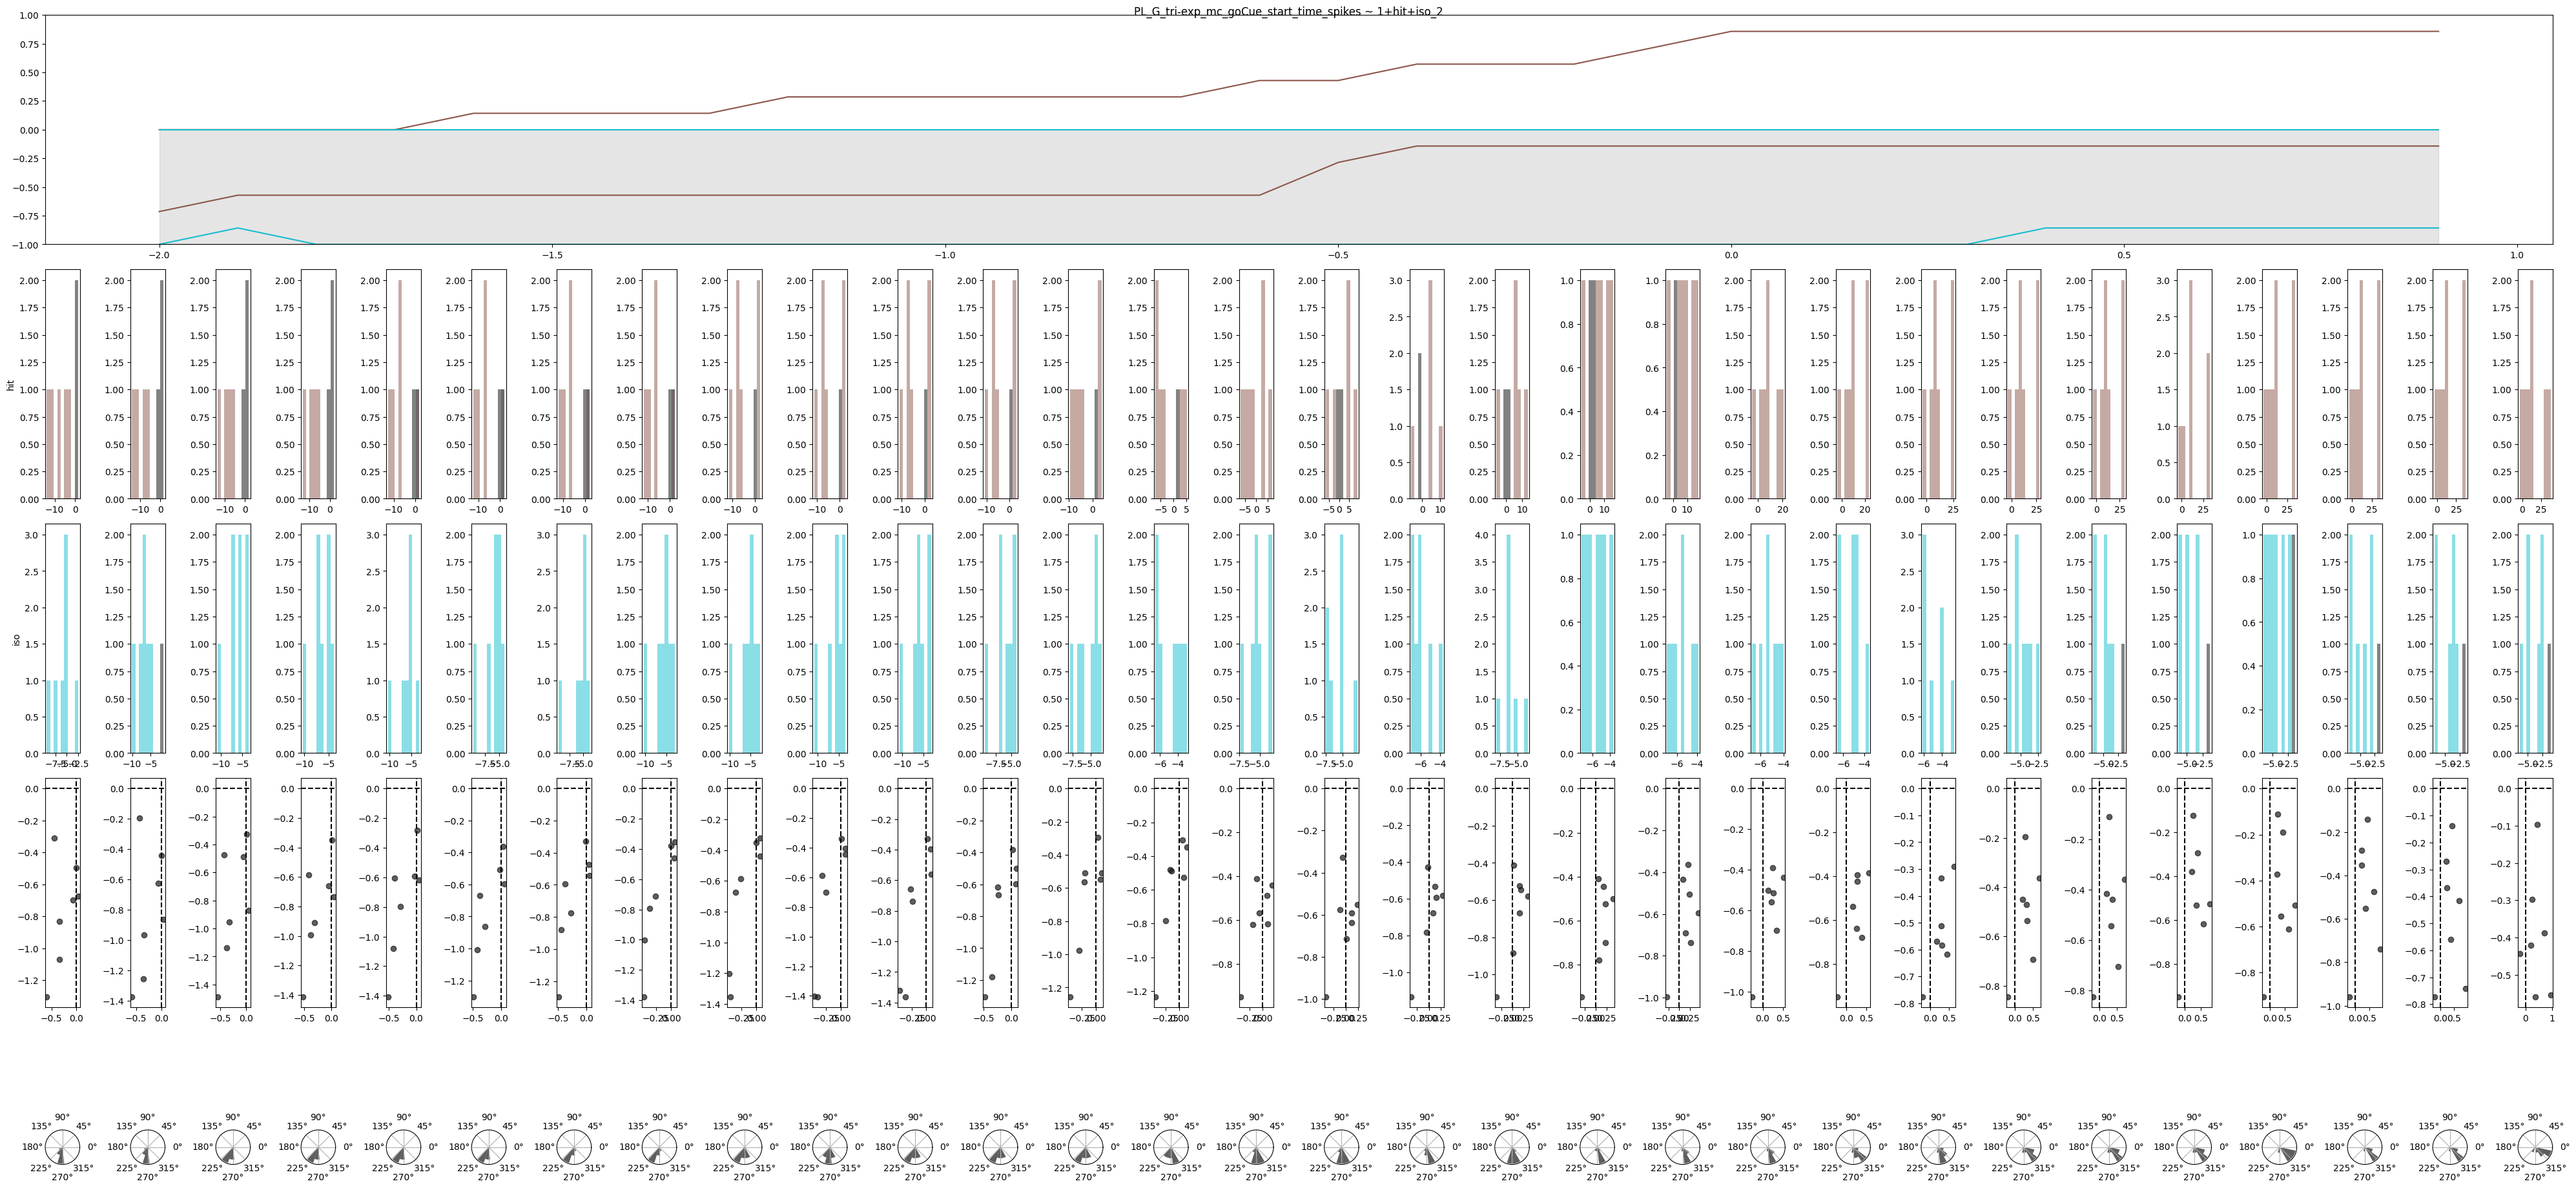

In [11]:
# animal-wise GLM
print(
    f"Animal-wise GLM with parameters: \n"
    f"Processing region: {params_dict_hit['region']}, "
    f"channel: {params_dict_hit['channel']}, "
    f"align: {params_dict_hit['align']}, "
    f"window size: {params_dict_hit['window_size']}, "
    f"threshold: {params_dict_hit['thresh']}, "
    f"formula: {params_dict_hit['formula']}"
)

results = population_GLM_ani(session_list, **params_dict_hit)

save_dir = os.path.join(target_folder, 'population_GLM_results')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
formula_clean = (
    params_dict_hit["formula"]
    .replace(" ", "")
    .replace("+", "_")
    .replace("*", "x")
    .split("~")[1]
)
file_name = (
    f"population_GLM_animal-wise_{params_dict_hit['region']}_{params_dict_hit['channel']}_"
    f"{params_dict_hit['align']}_win{params_dict_hit['window_size']}_"
    f"thresh{params_dict_hit['thresh']}_formula_{formula_clean}.pkl"
)
with open(os.path.join(save_dir, file_name), 'wb') as f:
    pickle.dump(params_dict_hit, f)
    pickle.dump(results, f)
print(f'Saved results to {os.path.join(save_dir, file_name)}')
results['fig'].savefig(os.path.join(save_dir, file_name.replace('.pkl', '.pdf')), dpi=300)
results['fig'].show()

Session-wise GLM with parameters: 
Processing region: PL, channel: G_tri-exp_mc, align: goCue_start_time, window size: 0.75, threshold: 0.5, formula: spikes ~ 1+svs+iso
Parsing session_id: behavior_669489_2023-06-24_14-56-01, aniID: 669489
Parsing session_id: behavior_669489_2023-06-26_16-23-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-27_14-20-19, aniID: 669489
Parsing session_id: behavior_669489_2023-06-28_13-10-12, aniID: 669489
Parsing session_id: behavior_669489_2023-06-29_16-16-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-30_12-51-58, aniID: 669489
Parsing session_id: behavior_669489_2023-07-01_16-31-54, aniID: 669489
Parsing session_id: behavior_669489_2023-07-02_12-49-06, aniID: 669489
Parsing session_id: behavior_669489_2023-07-03_11-31-11, aniID: 669489
Parsing session_id: behavior_669489_2023-07-04_14-24-45, aniID: 669489
Parsing session_id: behavior_669489_2023-07-05_15-44-55, aniID: 669489
Parsing session_id: behavior_669489_2023-07-06_13-

Parsing session_id: behavior_669489_2023-06-26_16-23-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-26_16-23-02, aniID: 669489
Parsing session_id: behavior_669489_2023-07-02_12-49-06, aniID: 669489
Parsing session_id: behavior_669489_2023-07-02_12-49-06, aniID: 669489
Parsing session_id: behavior_669489_2023-06-24_14-56-01, aniID: 669489
Parsing session_id: behavior_669489_2023-06-24_14-56-01, aniID: 669489
Parsing session_id: behavior_669489_2023-07-03_11-31-11, aniID: 669489
Parsing session_id: behavior_669489_2023-07-03_11-31-11, aniID: 669489
Parsing session_id: behavior_669489_2023-06-29_16-16-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-29_16-16-02, aniID: 669489
Parsing session_id: behavior_669489_2023-07-07_15-15-49, aniID: 669489
Parsing session_id: behavior_669489_2023-07-07_15-15-49, aniID: 669489
Parsing session_id: behavior_669489_2023-07-06_13-50-08, aniID: 669489
Parsing session_id: behavior_669489_2023-07-06_13-50-08, aniID: 669489
Parsin

/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:306: RuntimeWarning: Mean of empty slice
  aligned_matrix[i, j] = np.nanmean(aligned_signal[window_mask])


Parsing session_id: behavior_754896_2025-01-03_17-20-19, aniID: 754896
Parsing session_id: behavior_754896_2025-01-03_17-20-19, aniID: 754896


/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:321: RuntimeWarning: Mean of empty slice
  mean_psth = np.nanmean(aligned_matrix, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Parsing session_id: behavior_754898_2025-01-01_20-40-03, aniID: 754898
Parsing session_id: behavior_754898_2025-01-02_17-54-29, aniID: 754898
Parsing session_id: behavior_754898_2025-01-01_20-40-03, aniID: 754898
Parsing session_id: behavior_754898_2025-01-02_17-54-29, aniID: 754898
Parsing session_id: behavior_754898_2024-12-26_16-22-54, aniID: 754898
Parsing session_id: behavior_754898_2024-12-26_16-22-54, aniID: 754898
Parsing session_id: behavior_754896_2025-01-09_16-22-47, aniID: 754896
Parsing session_id: behavior_754896_2025-01-09_16-22-47, aniID: 754896
Parsing session_id: behavior_754898_2025-01-04_18-49-39, aniID: 754898
Parsing session_id: behavior_754898_2025-01-04_18-49-39, aniID: 754898
Parsing session_id: behavior_754896_2025-01-07_14-08-54, aniID: 754896
Parsing session_id: behavior_754896_2025-01-07_14-08-54, aniID: 754896
Parsing session_id: behavior_754898_2024-12-28_19-23-45, aniID: 754898
Parsing session_id: behavior_754898_2024-12-28_19-23-45, aniID: 754898
Parsin

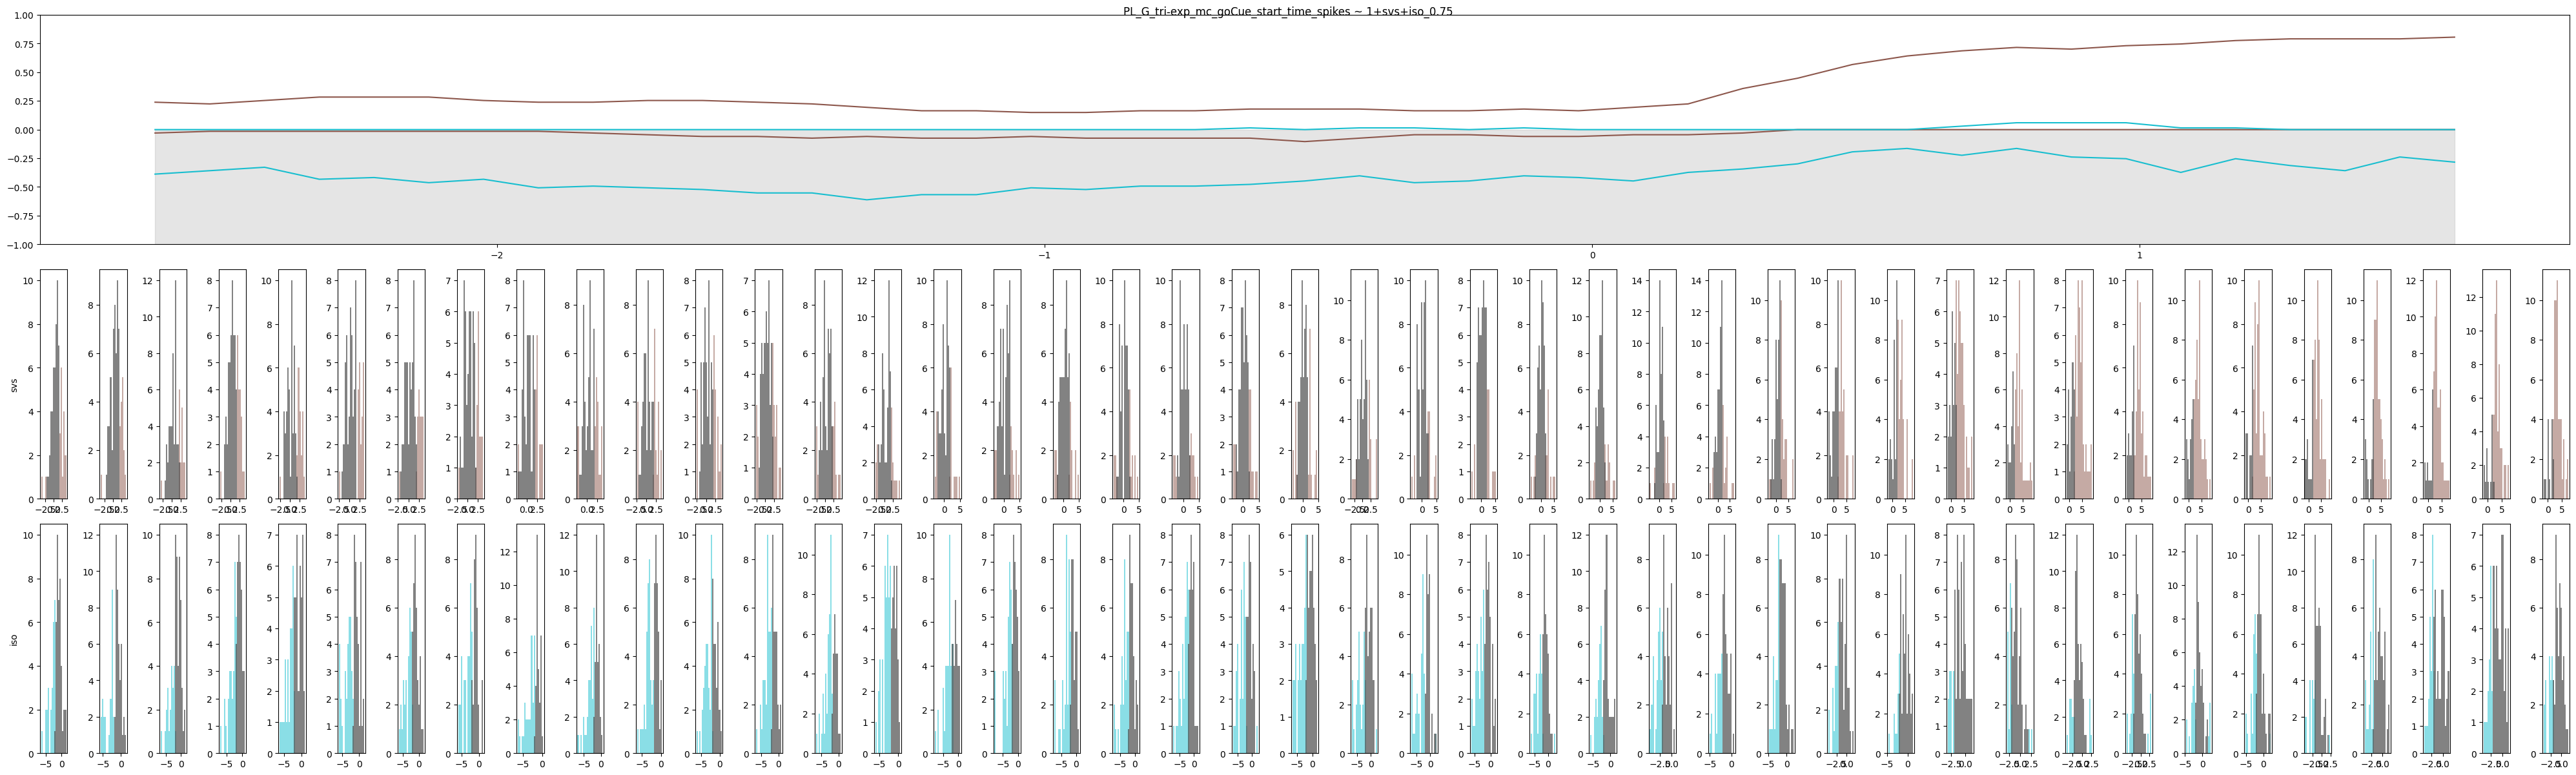

In [12]:
# Switch: session-wise GLM
region_curr = 'PL'
channel_curr = 'G_tri-exp_mc' 
align_curr = 'goCue_start_time'
window_size_curr = 0.75
thresh_curr = 0.5
formula = 'spikes ~ 1+svs+iso'
post = 2
pre = 3

params_dict_svs = {
    'region': region_curr,
    'channel': channel_curr,
    'align': align_curr,
    'window_size': window_size_curr,
    'formula': formula,
    'pre_time': pre,
    'post_time': post,
    'thresh': thresh_curr,
    'step_size': 0.1,
    'polar_regressors': ['hit', 'iso']
}

print(
    f"Session-wise GLM with parameters: \n"
    f"Processing region: {params_dict_svs['region']}, "
    f"channel: {params_dict_svs['channel']}, "
    f"align: {params_dict_svs['align']}, "
    f"window size: {params_dict_svs['window_size']}, "
    f"threshold: {params_dict_svs['thresh']}, "
    f"formula: {params_dict_svs['formula']}"
)

results = population_GLM(session_list, **params_dict_svs)

save_dir = os.path.join(target_folder, 'population_GLM_results')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
formula_clean = (
    params_dict_svs["formula"]
    .replace(" ", "")
    .replace("+", "_")
    .replace("*", "x")
    .split("~")[1]
)
file_name = (
    f"population_GLM_session-wise_{params_dict_svs['region']}_{params_dict_svs['channel']}_"
    f"{params_dict_svs['align']}_win{params_dict_svs['window_size']}_"
    f"thresh{params_dict_svs['thresh']}_formula_{formula_clean}.pkl"
)
with open(os.path.join(save_dir, file_name), 'wb') as f:
    pickle.dump(params_dict_svs, f)
    pickle.dump(results, f)
print(f'Saved results to {os.path.join(save_dir, file_name)}')
results['fig'].savefig(os.path.join(save_dir, file_name.replace('.pkl', '.pdf')), dpi=300)
results['fig'].show()

Animal-wise GLM with parameters: 
Processing region: PL, channel: G_tri-exp_mc, align: goCue_start_time, window size: 0.75, threshold: 0.5, formula: spikes ~ 1+svs+iso
Parsing session_id: behavior_669489_2023-06-24_14-56-01, aniID: 669489
Parsing session_id: behavior_669489_2023-06-26_16-23-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-27_14-20-19, aniID: 669489
Parsing session_id: behavior_669489_2023-06-28_13-10-12, aniID: 669489
Parsing session_id: behavior_669489_2023-06-29_16-16-02, aniID: 669489
Parsing session_id: behavior_669489_2023-06-30_12-51-58, aniID: 669489
Parsing session_id: behavior_669489_2023-07-01_16-31-54, aniID: 669489
Parsing session_id: behavior_669489_2023-07-02_12-49-06, aniID: 669489
Parsing session_id: behavior_669489_2023-07-03_11-31-11, aniID: 669489
Parsing session_id: behavior_669489_2023-07-04_14-24-45, aniID: 669489
Parsing session_id: behavior_669489_2023-07-05_15-44-55, aniID: 669489
Parsing session_id: behavior_669489_2023-07-06_13-5

Parsing session_id: behavior_699461_2023-12-19_11-14-31, aniID: 699461
Parsing session_id: behavior_749624_2025-01-04_12-44-49, aniID: 749624
Parsing session_id: behavior_749624_2025-01-04_12-44-49, aniID: 749624
Parsing session_id: behavior_699461_2023-12-19_11-14-31, aniID: 699461
Parsing session_id: behavior_669489_2023-06-27_14-20-19, aniID: 669489
Parsing session_id: behavior_669489_2023-06-27_14-20-19, aniID: 669489
Parsing session_id: behavior_699462_2024-01-06_13-39-52, aniID: 699462
Parsing session_id: behavior_699462_2024-01-06_13-39-52, aniID: 699462
Parsing session_id: behavior_701707_2024-01-03_16-52-16, aniID: 701707
Parsing session_id: behavior_701707_2024-01-03_16-52-16, aniID: 701707
Parsing session_id: behavior_699472_2024-01-02_13-53-59, aniID: 699472
Parsing session_id: behavior_699472_2024-01-02_13-53-59, aniID: 699472
Parsing session_id: behavior_754898_2024-12-30_17-40-08, aniID: 754898
Parsing session_id: behavior_754898_2024-12-30_17-40-08, aniID: 754898
Parsin

/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:306: RuntimeWarning: Mean of empty slice
  aligned_matrix[i, j] = np.nanmean(aligned_signal[window_mask])
/root/capsule/code/beh_ephys_analysis/utils/photometry_utils.py:321: RuntimeWarning: Mean of empty slice
  mean_psth = np.nanmean(aligned_matrix, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Parsing session_id: behavior_754896_2025-01-09_16-22-47, aniID: 754896
Parsing session_id: behavior_754896_2025-01-09_16-22-47, aniID: 754896
Parsing session_id: behavior_672850_2023-07-03_17-29-31, aniID: 672850
Parsing session_id: behavior_669489_2023-07-02_12-49-06, aniID: 669489
Parsing session_id: behavior_754895_2025-01-09_15-08-04, aniID: 754895
Parsing session_id: behavior_669489_2023-07-02_12-49-06, aniID: 669489
Parsing session_id: behavior_672850_2023-07-03_17-29-31, aniID: 672850
Parsing session_id: behavior_754895_2025-01-09_15-08-04, aniID: 754895
Parsing session_id: behavior_699462_2024-01-11_10-59-40, aniID: 699462
Parsing session_id: behavior_699462_2024-01-11_10-59-40, aniID: 699462
Parsing session_id: behavior_699472_2024-01-06_14-52-56, aniID: 699472
Parsing session_id: behavior_699472_2024-01-06_14-52-56, aniID: 699472
Parsing session_id: behavior_699461_2024-01-04_09-43-43, aniID: 699461
Parsing session_id: behavior_699461_2024-01-04_09-43-43, aniID: 699461
Parsin

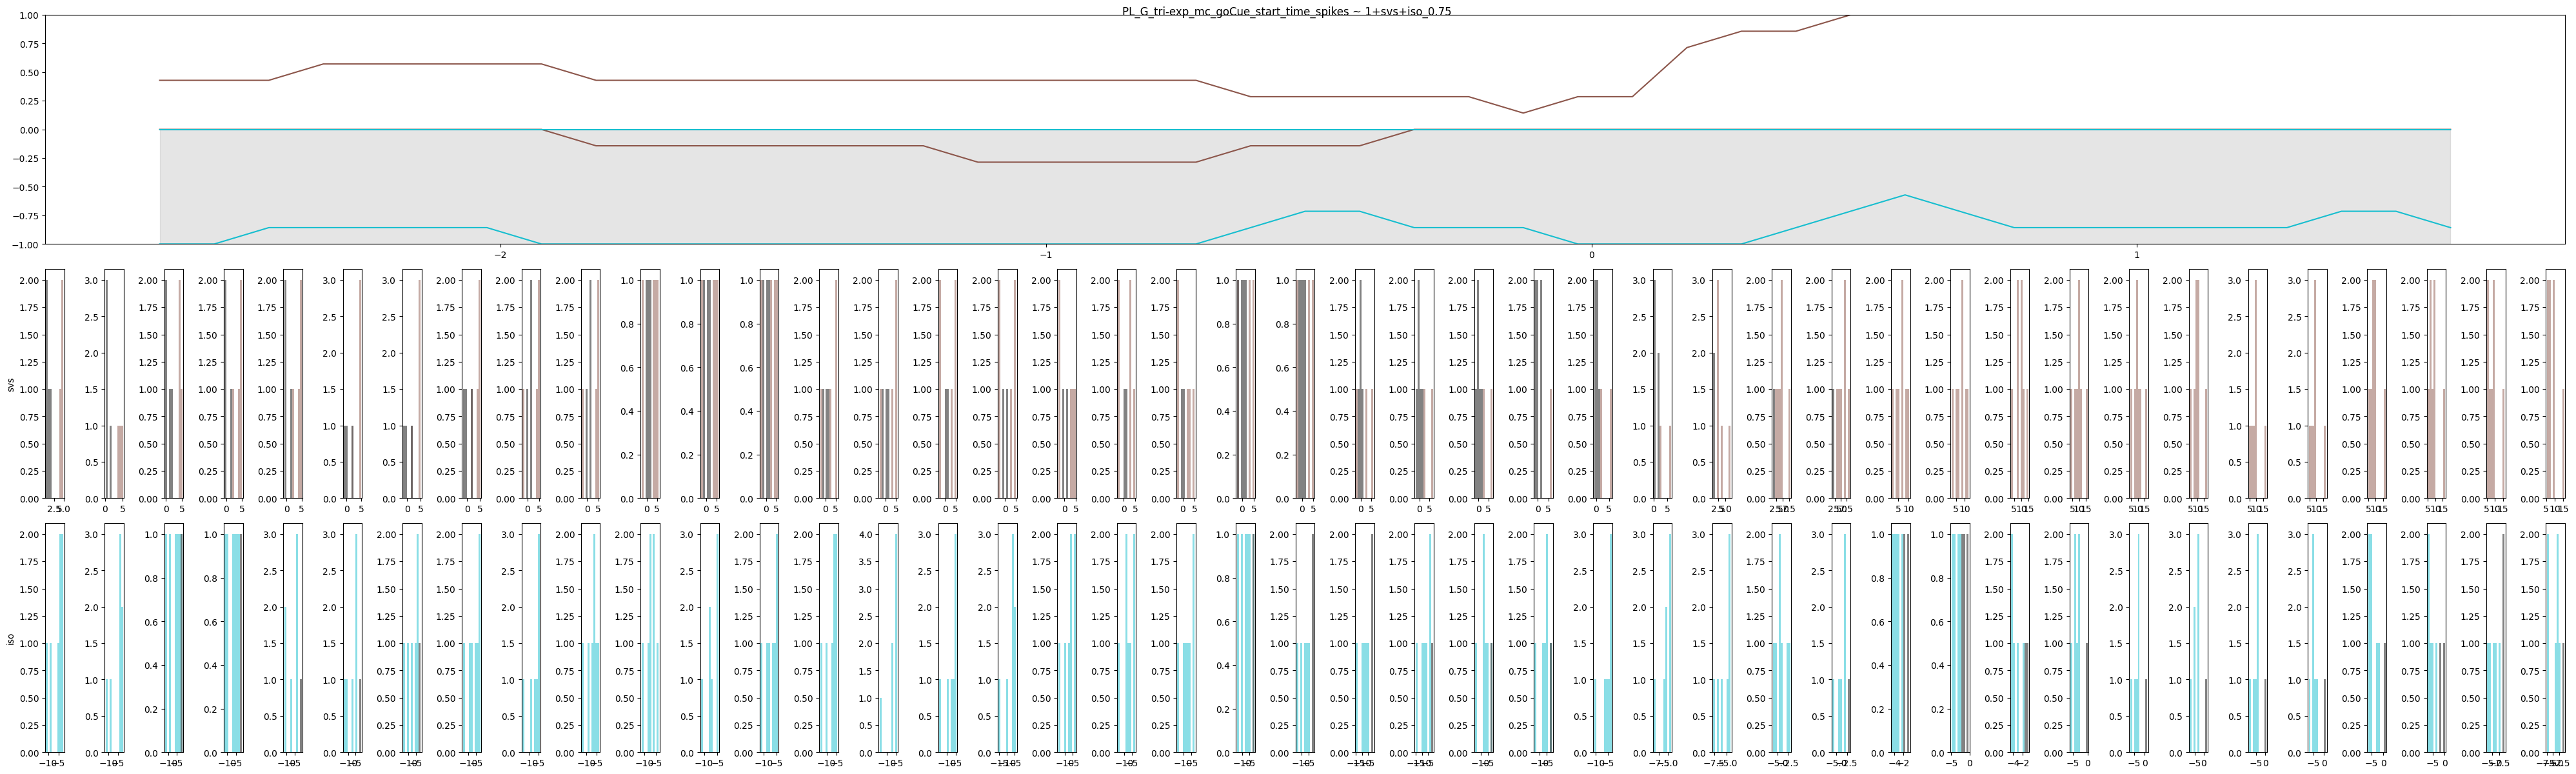

In [13]:
# Switch: animal-wise GLM

print(
    f"Animal-wise GLM with parameters: \n"
    f"Processing region: {params_dict_svs['region']}, "
    f"channel: {params_dict_svs['channel']}, "
    f"align: {params_dict_svs['align']}, "
    f"window size: {params_dict_svs['window_size']}, "
    f"threshold: {params_dict_svs['thresh']}, "
    f"formula: {params_dict_svs['formula']}"
)

results = population_GLM_ani(session_list, **params_dict_svs)

save_dir = os.path.join(target_folder, 'population_GLM_results')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
formula_clean = (
    params_dict_svs["formula"]
    .replace(" ", "")
    .replace("+", "_")
    .replace("*", "x")
    .split("~")[1]
)
file_name = (
    f"population_GLM_animal-wise_{params_dict_svs['region']}_{params_dict_svs['channel']}_"
    f"{params_dict_svs['align']}_win{params_dict_svs['window_size']}_"
    f"thresh{params_dict_svs['thresh']}_formula_{formula_clean}.pkl"
)
with open(os.path.join(save_dir, file_name), 'wb') as f:
    pickle.dump(params_dict_svs, f)
    pickle.dump(results, f)
print(f'Saved results to {os.path.join(save_dir, file_name)}')
results['fig'].savefig(os.path.join(save_dir, file_name.replace('.pkl', '.pdf')), dpi=300)
results['fig'].show()